# Imports

In [5]:
import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, f_oneway, levene, kruskal, wilcoxon
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch


# Testes Estatísticos

## Melhores Desempenhos

In [29]:
# Caminho da pasta
str_DF = 'Circles'  # Nome da pasta dentro de CSV
metric = "Accuracy"  # "Accuracy" or "F1_Scores"
directory = f"./CSV/{str_DF}/Metrics/"

# Criar pasta para salvar as imagens
output_dir = f"./CSV/{str_DF}/Images/"
os.makedirs(output_dir, exist_ok=True)

# Dicionário para armazenar os DataFrames
dataframes = {}
filename_list = []

# Ler os arquivos CSV
for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        filepath = os.path.join(directory, filename)
        # Nome da variável será o nome do arquivo sem extensão
        var_name = os.path.splitext(filename)[0]
        dataframes[var_name] = pd.read_csv(filepath)
        filename_list.append(var_name)

# Tabela 1: Maior valor de cada métrica para cada arquivo
def criar_tabela_metricas_maximas(dataframes):
    """
    Cria uma tabela onde cada linha mostra o maior valor de cada métrica
    para cada arquivo.
    """
    
    resultados = []
    metricas_disponiveis = []
    
    # Identificar todas as métricas disponíveis
    for df in dataframes.values():
        for col in df.columns:
            if col in ['Accuracy', 'F1_Scores'] and col not in metricas_disponiveis:
                metricas_disponiveis.append(col)
    
    for nome_arquivo, df in dataframes.items():
        resultado = {'Arquivo': nome_arquivo}
        
        # Para cada métrica disponível, encontrar o valor máximo
        for metrica in metricas_disponiveis:
            if metrica in df.columns:
                max_valor = df[metrica].max()
                resultado[f'Max_{metrica}'] = max_valor
            else:
                resultado[f'Max_{metrica}'] = np.nan
        
        resultados.append(resultado)
    
    tabela_metricas = pd.DataFrame(resultados)
    return tabela_metricas, metricas_disponiveis

# Tabela 2: Maior acurácia com seu F1-Score correspondente
def criar_tabela_acuracia_f1(dataframes):
    """
    Cria uma tabela que mostra a maior acurácia de cada arquivo
    acompanhada do F1-Score correspondente.
    """
    
    resultados = []
    
    for nome_arquivo, df in dataframes.items():
        if 'Accuracy' in df.columns:
            # Encontrar a linha com a maior acurácia
            max_accuracy = df['Accuracy'].max()
            linha_max_accuracy = df[df['Accuracy'] == max_accuracy].iloc[0]
            
            resultado = {
                'Arquivo': nome_arquivo,
                'Max_Accuracy': max_accuracy
            }
            
            # Adicionar o F1-Score correspondente, se disponível
            if 'F1_Scores' in df.columns:
                # Usar o F1-Score da mesma linha onde ocorreu a máxima acurácia
                f1_correspondente = linha_max_accuracy['F1_Scores']
                resultado['F1_Score_Correspondente'] = f1_correspondente
            else:
                resultado['F1_Score_Correspondente'] = np.nan
            
            resultados.append(resultado)
    
    tabela_acuracia_f1 = pd.DataFrame(resultados)
    # Ordenar pela maior acurácia
    tabela_acuracia_f1 = tabela_acuracia_f1.sort_values(by='Max_Accuracy', ascending=False)
    
    return tabela_acuracia_f1

# NOVA TABELA 3: Estatísticas completas para cada métrica
def criar_tabela_estatisticas_completas(dataframes):
    """
    Cria tabelas com média, máximo e mínimo de cada métrica para cada arquivo.
    Retorna um dicionário com tabelas para cada métrica disponível.
    """
    
    metricas_disponiveis = []
    
    # Identificar todas as métricas disponíveis
    for df in dataframes.values():
        for col in df.columns:
            if col in ['Accuracy', 'F1_Scores'] and col not in metricas_disponiveis:
                metricas_disponiveis.append(col)
    
    tabelas_estatisticas = {}
    
    for metrica in metricas_disponiveis:
        resultados = []
        
        for nome_arquivo, df in dataframes.items():
            if metrica in df.columns:
                # Calcular estatísticas
                media_valor = df[metrica].mean()
                max_valor = df[metrica].max()
                min_valor = df[metrica].min()
                std_valor = df[metrica].std()
                
                resultado = {
                    'Arquivo': nome_arquivo,
                    f'Media_{metrica}': media_valor,
                    f'Max_{metrica}': max_valor,
                    f'Min_{metrica}': min_valor,
                    f'Std_{metrica}': std_valor
                }
                
                resultados.append(resultado)
        
        if resultados:  # Só criar tabela se houver dados
            tabela_metrica = pd.DataFrame(resultados)
            # Ordenar pela média em ordem decrescente
            tabela_metrica = tabela_metrica.sort_values(by=f'Media_{metrica}', ascending=False)
            tabelas_estatisticas[metrica] = tabela_metrica
    
    return tabelas_estatisticas

# NOVA TABELA 4: Resumo geral com todas as métricas
def criar_tabela_resumo_geral(dataframes):
    """
    Cria uma tabela resumo com todas as estatísticas para todas as métricas.
    """
    
    metricas_disponiveis = []
    
    # Identificar todas as métricas disponíveis
    for df in dataframes.values():
        for col in df.columns:
            if col in ['Accuracy', 'F1_Scores'] and col not in metricas_disponiveis:
                metricas_disponiveis.append(col)
    
    resultados = []
    
    for nome_arquivo, df in dataframes.items():
        resultado = {'Arquivo': nome_arquivo}
        
        for metrica in metricas_disponiveis:
            if metrica in df.columns:
                # Calcular todas as estatísticas
                resultado[f'Media_{metrica}'] = df[metrica].mean()
                resultado[f'Max_{metrica}'] = df[metrica].max()
                resultado[f'Min_{metrica}'] = df[metrica].min()
                resultado[f'Std_{metrica}'] = df[metrica].std()
            else:
                resultado[f'Media_{metrica}'] = np.nan
                resultado[f'Max_{metrica}'] = np.nan
                resultado[f'Min_{metrica}'] = np.nan
                resultado[f'Std_{metrica}'] = np.nan
        
        resultados.append(resultado)
    
    tabela_resumo = pd.DataFrame(resultados)
    return tabela_resumo, metricas_disponiveis

# Criar visualizações em formato JPG
def criar_visualizacoes_jpg(tabela_metricas, tabela_acuracia_f1, tabelas_estatisticas, tabela_resumo, metricas_disponiveis, output_dir):
    """
    Cria e salva visualizações em formato JPG para todas as tabelas.
    """
    
    # CONFIGURAÇÃO DE ESCALAS - MODIFICAR AQUI PARA AJUSTAR AS ESCALAS
    # ================================================================
    ESCALA_COLUNA_ARQUIVO = 1.0    # Escala para a coluna "Arquivo" (maior)
    ESCALA_COLUNAS_NUMERICAS = 0.3  # Escala para as colunas numéricas (menor)
    # ================================================================

    # 1. Tabela formatada - Métricas Máximas (original)
    fig, ax = plt.subplots(figsize=(18, 12))
    ax.axis('tight')
    ax.axis('off')
    
    tabela_visual_metricas = tabela_metricas.copy()
    
    # Formatar números
    for col in tabela_visual_metricas.columns:
        if 'Max_' in col:
            tabela_visual_metricas[col] = tabela_visual_metricas[col].apply(
                lambda x: f'{x:.4f}' if isinstance(x, (int, float)) and not np.isnan(x) else 'N/A')
    
    table1 = ax.table(cellText=tabela_visual_metricas.values,
                     colLabels=tabela_visual_metricas.columns,
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0.7, 1, 0.25])
    
    table1.auto_set_font_size(False)
    table1.set_fontsize(10)
    
    # Aplicar escalas diferentes para cada coluna
    col_widths1 = [ESCALA_COLUNA_ARQUIVO] + [ESCALA_COLUNAS_NUMERICAS] * (len(tabela_visual_metricas.columns) - 1)
    table1.scale(1, 1)
    
    # Ajustar larguras das colunas individualmente
    for j, width in enumerate(col_widths1):
        for i in range(len(tabela_visual_metricas) + 1):
            table1[(i, j)].set_width(width)
    
    # 2. Tabela formatada - Acurácia com F1-Score (original)
    tabela_visual_acuracia = tabela_acuracia_f1.copy()
    
    # Formatar números
    for col in ['Max_Accuracy', 'F1_Score_Correspondente']:
        if col in tabela_visual_acuracia.columns:
            tabela_visual_acuracia[col] = tabela_visual_acuracia[col].apply(
                lambda x: f'{x:.4f}' if isinstance(x, (int, float)) and not np.isnan(x) else 'N/A')
    
    table2 = ax.table(cellText=tabela_visual_acuracia.values,
                     colLabels=tabela_visual_acuracia.columns,
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0.35, 1, 0.25])
    
    table2.auto_set_font_size(False)
    table2.set_fontsize(10)
    
    # Aplicar escalas diferentes para cada coluna
    col_widths2 = [ESCALA_COLUNA_ARQUIVO] + [ESCALA_COLUNAS_NUMERICAS] * (len(tabela_visual_acuracia.columns) - 1)
    table2.scale(1, 1)
    
    # Ajustar larguras das colunas individualmente
    for j, width in enumerate(col_widths2):
        for i in range(len(tabela_visual_acuracia) + 1):
            table2[(i, j)].set_width(width)
    
    # 3. NOVA: Tabela resumo geral (apenas primeiras colunas para visualização)
    if not tabela_resumo.empty:
        # Pegar apenas algumas colunas para não sobrecarregar a visualização
        colunas_resumo = ['Arquivo']
        for metrica in metricas_disponiveis:
            colunas_resumo.extend([f'Media_{metrica}', f'Max_{metrica}', f'Min_{metrica}'])
        
        tabela_visual_resumo = tabela_resumo[colunas_resumo].copy()
        
        # Formatar números
        for col in tabela_visual_resumo.columns:
            if col != 'Arquivo':
                tabela_visual_resumo[col] = tabela_visual_resumo[col].apply(
                    lambda x: f'{x:.4f}' if isinstance(x, (int, float)) and not np.isnan(x) else 'N/A')
        
        table3 = ax.table(cellText=tabela_visual_resumo.values,
                         colLabels=tabela_visual_resumo.columns,
                         cellLoc='center',
                         loc='center',
                         bbox=[0, 0, 1, 0.25])
        
        table3.auto_set_font_size(False)
        table3.set_fontsize(8)  # Fonte menor para caber mais colunas
        
        col_widths3 = [ESCALA_COLUNA_ARQUIVO] + [ESCALA_COLUNAS_NUMERICAS] * (len(tabela_visual_resumo.columns) - 1)
        table3.scale(1, 1)
        
        for j, width in enumerate(col_widths3):
            for i in range(len(tabela_visual_resumo) + 1):
                table3[(i, j)].set_width(width)
    
    # Colorir cabeçalhos
    for i in range(len(tabela_visual_metricas.columns)):
        table1[(0, i)].set_facecolor("#FF00F2")
        table1[(0, i)].set_text_props(weight='bold', color='white')
    
    for i in range(len(tabela_visual_acuracia.columns)):
        table2[(0, i)].set_facecolor("#2196F3")
        table2[(0, i)].set_text_props(weight='bold', color='white')
    
    if not tabela_resumo.empty:
        for i in range(len(tabela_visual_resumo.columns)):
            table3[(0, i)].set_facecolor("#4CAF50")
            table3[(0, i)].set_text_props(weight='bold', color='white')
    
    plt.title('Tabelas Comparativas - Análise de Métricas', fontsize=13, fontweight='bold', pad=30)
    plt.tight_layout()
    plt.savefig(f'{output_dir}tabelas_comparativas_combinadas.jpg', dpi=300, bbox_inches='tight')
    plt.close()
    
    # 4. NOVAS TABELAS INDIVIDUAIS PARA ESTATÍSTICAS COMPLETAS
    for metrica, tabela_estatistica in tabelas_estatisticas.items():
        fig, ax = plt.subplots(figsize=(14, 10))
        ax.axis('tight')
        ax.axis('off')
        
        tabela_visual = tabela_estatistica.copy()
        
        # Formatar números
        for col in tabela_visual.columns:
            if col != 'Arquivo':
                tabela_visual[col] = tabela_visual[col].apply(
                    lambda x: f'{x:.4f}' if isinstance(x, (int, float)) and not np.isnan(x) else 'N/A')
        
        table = ax.table(cellText=tabela_visual.values,
                        colLabels=tabela_visual.columns,
                        cellLoc='center',
                        loc='center',
                        bbox=[0, 0, 1, 1])
        
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        
        # Aplicar escalas diferentes
        col_widths = [ESCALA_COLUNA_ARQUIVO] + [ESCALA_COLUNAS_NUMERICAS] * (len(tabela_visual.columns) - 1)
        table.scale(1.2, 1.8)
        
        for j, width in enumerate(col_widths):
            for i in range(len(tabela_visual) + 1):
                table[(i, j)].set_width(width)
        
        # Colorir cabeçalho
        for i in range(len(tabela_visual.columns)):
            table[(0, i)].set_facecolor("#FF9800")
            table[(0, i)].set_text_props(weight='bold', color='white')
        
        # Colorir linhas alternadas
        for i in range(1, len(tabela_visual) + 1):
            if i % 2 == 0:
                for j in range(len(tabela_visual.columns)):
                    table[(i, j)].set_facecolor('#f0f0f0')
        
        plt.title(f'Estatísticas Completas - {metrica}', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'{output_dir}tabela_estatisticas_{metrica.lower()}.jpg', dpi=300, bbox_inches='tight')
        plt.close()
    
    # 5. Tabela resumo geral individual
    if not tabela_resumo.empty:
        fig, ax = plt.subplots(figsize=(20, 12))
        ax.axis('tight')
        ax.axis('off')
        
        tabela_visual_resumo = tabela_resumo.copy()
        
        # Formatar números
        for col in tabela_visual_resumo.columns:
            if col != 'Arquivo':
                tabela_visual_resumo[col] = tabela_visual_resumo[col].apply(
                    lambda x: f'{x:.4f}' if isinstance(x, (int, float)) and not np.isnan(x) else 'N/A')
        
        table = ax.table(cellText=tabela_visual_resumo.values,
                        colLabels=tabela_visual_resumo.columns,
                        cellLoc='center',
                        loc='center',
                        bbox=[0, 0, 1, 1])
        
        table.auto_set_font_size(False)
        table.set_fontsize(9)  # Fonte menor para caber todas as colunas
        
        col_widths = [ESCALA_COLUNA_ARQUIVO] + [ESCALA_COLUNAS_NUMERICAS] * (len(tabela_visual_resumo.columns) - 1)
        table.scale(1.1, 1.5)
        
        for j, width in enumerate(col_widths):
            for i in range(len(tabela_visual_resumo) + 1):
                table[(i, j)].set_width(width)
        
        for i in range(len(tabela_visual_resumo.columns)):
            table[(0, i)].set_facecolor("#9C27B0")
            table[(0, i)].set_text_props(weight='bold', color='white')
        
        for i in range(1, len(tabela_visual_resumo) + 1):
            if i % 2 == 0:
                for j in range(len(tabela_visual_resumo.columns)):
                    table[(i, j)].set_facecolor('#f0f0f0')
        
        plt.title('Resumo Geral - Todas as Métricas e Estatísticas', fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'{output_dir}tabela_resumo_geral.jpg', dpi=300, bbox_inches='tight')
        plt.close()

# Executar a análise
print("=" * 80)
print("GERANDO TABELAS E VISUALIZAÇÕES")
print("=" * 80)

# Criar todas as tabelas
tabela_metricas, metricas_disponiveis = criar_tabela_metricas_maximas(dataframes)
tabela_acuracia_f1 = criar_tabela_acuracia_f1(dataframes)
tabelas_estatisticas = criar_tabela_estatisticas_completas(dataframes)
tabela_resumo, todas_metricas = criar_tabela_resumo_geral(dataframes)

# Criar visualizações
criar_visualizacoes_jpg(tabela_metricas, tabela_acuracia_f1, tabelas_estatisticas, tabela_resumo, metricas_disponiveis, output_dir)

print("Visualizações criadas com sucesso!")
print(f"Arquivos salvos em: {output_dir}")

# Mostrar resumos no console
print("\n" + "=" * 80)
print("TABELA 1: MÁXIMOS DE CADA MÉTRICA POR ARQUIVO")
print("=" * 80)
print(tabela_metricas.to_string(index=False))

print("\n" + "=" * 80)
print("TABELA 2: MAIOR ACURÁCIA COM F1-SCORE CORRESPONDENTE")
print("=" * 80)
print(tabela_acuracia_f1.to_string(index=False))

# Mostrar novas tabelas
for metrica, tabela in tabelas_estatisticas.items():
    print(f"\n" + "=" * 80)
    print(f"TABELA ESTATÍSTICAS: {metrica.upper()}")
    print("=" * 80)
    print(tabela.to_string(index=False))

if not tabela_resumo.empty:
    print("\n" + "=" * 80)
    print("TABELA RESUMO GERAL")
    print("=" * 80)
    # Mostrar apenas as primeiras linhas para não sobrecarregar o console
    print(tabela_resumo.head().to_string(index=False))

# Salvar todas as tabelas em CSV
tabela_metricas.to_csv(f'{output_dir}tabela1_metricas_maximas.csv', index=False)
tabela_acuracia_f1.to_csv(f'{output_dir}tabela2_acuracia_f1.csv', index=False)

for metrica, tabela in tabelas_estatisticas.items():
    tabela.to_csv(f'{output_dir}tabela_estatisticas_{metrica.lower()}.csv', index=False)

if not tabela_resumo.empty:
    tabela_resumo.to_csv(f'{output_dir}tabela_resumo_geral.csv', index=False)

print(f"\nTabelas salvas em CSV:")
print(f"1. {output_dir}tabela1_metricas_maximas.csv")
print(f"2. {output_dir}tabela2_acuracia_f1.csv")
for metrica in tabelas_estatisticas.keys():
    print(f"3. {output_dir}tabela_estatisticas_{metrica.lower()}.csv")
if not tabela_resumo.empty:
    print(f"4. {output_dir}tabela_resumo_geral.csv")

print("\nArquivos de imagem gerados:")
print("1. tabelas_comparativas_combinadas.jpg - Tabelas combinadas")
print("2. tabela1_metricas_maximas.jpg - Tabela 1 individual")
print("3. tabela2_acuracia_f1.jpg - Tabela 2 individual")
for metrica in tabelas_estatisticas.keys():
    print(f"4. tabela_estatisticas_{metrica.lower()}.jpg - Estatísticas {metrica}")
if not tabela_resumo.empty:
    print("5. tabela_resumo_geral.jpg - Resumo geral")

GERANDO TABELAS E VISUALIZAÇÕES
Visualizações criadas com sucesso!
Arquivos salvos em: ./CSV/Circles/Images/

TABELA 1: MÁXIMOS DE CADA MÉTRICA POR ARQUIVO
                                                      Arquivo  Max_Accuracy  Max_F1_Scores
   IQCNDsE_Coluna_circles_metrics_results_2025-09-09_14-51-27      0.500000       0.410135
    IQCNDsE_Linha_circles_metrics_results_2025-09-09_13-26-51      0.503333       0.418695
IQCpQ_tgt2_Coluna_circles_metrics_results_2025-09-21_16-22-00      0.503333       0.382694
 IQCpQ_tgt2_Linha_circles_metrics_results_2025-09-05_18-36-12      0.500000       0.373230
IQCpQ_tgt4_Coluna_circles_metrics_results_2025-09-19_08-37-37      0.513333       0.375736
 IQCpQ_tgt4_Linha_circles_metrics_results_2025-09-19_04-44-29      0.496667       0.359684
   IQC_AIL_Coluna_circles_metrics_results_2025-09-05_14-20-16      0.500000       0.431088
    IQC_AIL_Linha_circles_metrics_results_2025-09-05_13-02-37      0.490000       0.409718
 IQC_Angle_Coluna_circles

## Comparação dos Modelos

c:\Users\pichau\.conda\envs\qiskit\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\pichau\.conda\envs\qiskit\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


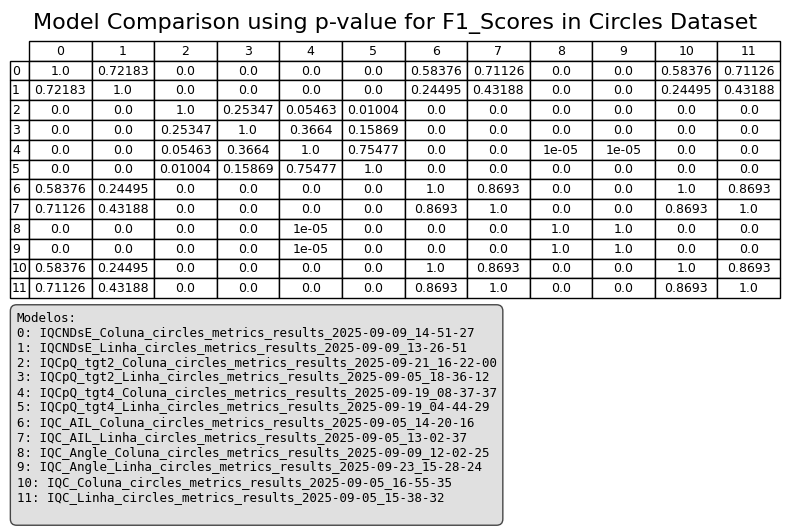

Tabela salva com legenda!


In [140]:
# Caminho da pasta
str_DF = 'Circles'  # Nome da pasta dentro de CSV
metric = "F1_Scores"  # "Accuracy" or "F1_Scores"
directory = f"./CSV/{str_DF}/Metrics/"

# Dicionário para armazenar os DataFrames
dataframes = {}

filename_list = []

for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        filepath = os.path.join(directory, filename)
        # Nome da variável será o nome do arquivo sem extensão
        var_name = os.path.splitext(filename)[0]
        dataframes[var_name] = pd.read_csv(filepath)
        filename_list.append(var_name)
'''
# Exemplo de acesso
for name in filename_list:
    print(f"DataFrame '{name}':")
    print(dataframes[name].head())  # Mostra as primeiras linhas do DataFrame
    print("\n")
'''
# -------------------------------
# TESTES ESTATÍSTICOS
N = len(filename_list)
pval_matrix = np.ones((N, N))  # matriz de p-valores, inicializada com 1

for i in range(N):
    for j in range(i+1, N):
        model_i = filename_list[i]
        model_j = filename_list[j]

        if model_i not in dataframes or model_j not in dataframes:
            continue

        dist_i = dataframes[model_i][metric].values
        dist_j = dataframes[model_j][metric].values

        # Teste de normalidade Shapiro-Wilk
        _, p_i = shapiro(dist_i)
        _, p_j = shapiro(dist_j)
        normal_i = p_i > 0.05
        normal_j = p_j > 0.05

        # Escolha do teste
        if normal_i and normal_j:
            _, pval = ttest_ind(dist_i, dist_j, equal_var=False)
        else:
            _, pval = wilcoxon(dist_i, dist_j, method='auto', zero_method='zsplit')#mannwhitneyu(dist_i, dist_j, alternative="two-sided")


        # Preenche matriz simétrica
        pval_matrix[i, j] = pval + 1e-16
        pval_matrix[j, i] = pval + 1e-16

numbers = [i for i in range(1, N+1)]
pval_df = pd.DataFrame(pval_matrix, index=numbers, columns=numbers)
#pval_df = pd.DataFrame(pval_matrix, index=filename_list, columns=filename_list)
# -------------------------------
# RESULTADO FINAL
# -------------------------------

pval_df=pval_df.round(5)

'''print("\n=== MATRIZ DE P-VALORES ===")

print(pval_df.round(5))'''

pval_df.to_csv(f"./CSV/{str_DF}/matriz_pvalores_{metric}_{str_DF}.csv")
# -------------------------------
# SALVAR TABELA COMO IMAGEM COM LEGENDA
# -------------------------------

df = pd.read_csv(f'./CSV/{str_DF}/matriz_pvalores_{metric}_{str_DF}.csv', index_col=0)

mapeamento = {}
for i, coluna in enumerate(filename_list):
    mapeamento[i] = coluna

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axis('tight')
ax.axis('off')

tabela = ax.table(cellText=df.values,  # Adiciona um valor pequeno para evitar zeros
                  colLabels=range(len(df.columns)),
                  rowLabels=range(len(df.index)),
                  cellLoc='center',
                  loc='center')

tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1, 1)  # Ajustar escala (largura, altura)

legenda_texto = "Modelos:\n"
for num, nome in mapeamento.items():
    legenda_texto += f"{num}: {nome}\n"

plt.figtext(0.027, -0.49, legenda_texto, fontsize=9, family='monospace', 
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.7))

plt.tight_layout()  # [left, bottom, right, top]

plt.suptitle(f"Model Comparison using p-value for {metric} in {str_DF} Dataset", fontsize=16, y=0.95)

plt.savefig(f'./CSV/{str_DF}/matriz_pvalores_{metric}_{str_DF}.jpg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("Tabela salva com legenda!")

## Thrash

In [ ]:
def load_and_merge_models(folder_path, model_prefixes, target_columns):
    """Carrega e aglutina arquivos CSV de múltiplos modelos."""
    model_data = {model: [] for model in model_prefixes}
    
    for file in os.listdir(folder_path):
        if file.endswith('.csv'):
            for model in model_prefixes:
                if file.startswith(model):
                    df = pd.read_csv(os.path.join(folder_path, file))
                    available_cols = [col for col in target_columns if col in df.columns]
                    model_data[model].append(df[available_cols])
                    break
    
    return {model: pd.concat(data, ignore_index=True) for model, data in model_data.items()}

def check_normality_and_homogeneity(data_dict, target_column, alpha=0.05):
    """Verifica normalidade (Shapiro-Wilk) e homocedasticidade (Levene)."""
    normality_results = {}
    all_normal = True
    data_to_compare = []
    
    for model, df in data_dict.items():
        if target_column in df.columns:
            data = df[target_column].dropna()
            stat, p = shapiro(data)
            normality_results[model] = {
                'p_value': p,
                'is_normal': p > alpha,
                'data': data
            }
            all_normal &= (p > alpha)
            data_to_compare.append(data)
        else:
            print(f"Aviso: Coluna '{target_column}' não encontrada no modelo {model}")
            normality_results[model] = {
                'p_value': np.nan,
                'is_normal': False,
                'data': None
            }
            all_normal = False
    
    # Verifica homocedasticidade apenas se todos forem normais
    homogeneous = False
    if all_normal and len(data_to_compare) >= 2:
        _, p_levene = levene(*data_to_compare)
        homogeneous = p_levene > alpha
    
    return normality_results, all_normal, homogeneous

def compare_models(data_dict, target_column, alpha=0.05):
    """Compara modelos com testes paramétricos (ANOVA/t-test) ou não paramétricos."""
    # Verifica suposições
    normality_results, all_normal, homogeneous = check_normality_and_homogeneity(
        data_dict, target_column, alpha
    )
    
    # Imprime resultados
    print("\nTeste de normalidade (Shapiro-Wilk):")
    for model, result in normality_results.items():
        print(f"{model}: p = {result['p_value']:.4f} | {'Normal' if result['is_normal'] else 'Não normal'}")
    
    if all_normal:
        print(f"\nTeste de homocedasticidade (Levene): {'Homogêneo' if homogeneous else 'Heterogêneo'}")
    
    # Prepara dados para comparação
    models = [k for k, v in normality_results.items() if v['data'] is not None]
    data_to_compare = [normality_results[model]['data'] for model in models]
    
    # Seleciona teste estatístico
    if len(models) == 2:
        if all_normal:
            stat, p = ttest_ind(*data_to_compare, equal_var=homogeneous)
            test_name = "Teste t de Student (Welch)" if not homogeneous else "Teste t de Student"
        else:
            stat, p = mannwhitneyu(*data_to_compare)
            test_name = "Teste de Mann-Whitney U"
    else:
        if all_normal:
            stat, p = f_oneway(*data_to_compare)
            test_name = "ANOVA unidirecional"
        else:
            stat, p = kruskal(*data_to_compare)
            test_name = "Teste de Kruskal-Wallis"
    
    # Executa e mostra resultados
    print(f"\n{test_name}:")
    print(f"Estatística = {stat:.4f}, p-value = {p:.4f}")
    
    if p < alpha:
        print(f"Conclusão (α={alpha}): Há diferenças significativas entre os modelos.")
        
        # Testes post-hoc
        if len(models) > 2:
            print("\nTestes post-hoc:")
            
            # Para ANOVA (Tukey HSD)
            if all_normal:
                tukey = pairwise_tukeyhsd(
                    endog=np.concatenate(data_to_compare),
                    groups=np.repeat(models, [len(x) for x in data_to_compare]),
                    alpha=alpha
                )
                print(tukey)
            
            # Para Kruskal-Wallis (Mann-Whitney U com correção Bonferroni)
            else:
                for (model1, data1), (model2, data2) in combinations(zip(models, data_to_compare), 2):
                    _, p_val = mannwhitneyu(data1, data2)
                    print(f"{model1} vs {model2}: p = {p_val:.4f} (Mann-Whitney U)")
    else:
        print(f"Conclusão (α={alpha}): Não há diferenças significativas.")

def main():
    # Configurações
    folder_path = "./CSV/"
    model_prefixes = ['IQC_Linha', 'IQC_Coluna', 'IQC_AIL_Linha', 'IQC_AIL_Coluna', 'IQC_Angle_Linha', 'IQC_Angle_Coluna', 'IQCpQ_NF4_Linha', 'IQCpQ_NF4_Coluna', 'IQCNDsE_Linha', 'IQCNDsE_Coluna']
    target_columns = ['Scores', 'F1_Scores', 'Negativity_Class_0']
    alpha = 0.05

    try:
        model_data = load_and_merge_models(folder_path, model_prefixes, target_columns)
        
        # Filtra modelos com dados
        valid_models = {k: v for k, v in model_data.items() if not v.empty}
        print("Modelos carregados:")
        for model, df in valid_models.items():
            print(f"- {model}: {len(df)} amostras | Colunas: {list(df.columns)}")
        
        # Análise para cada coluna
        for column in target_columns:
            print(f"\n{'='*50}\nAnálise para: {column}\n{'='*50}")
            compare_models(valid_models, column, alpha)
            
    except Exception as e:
        print(f"Erro: {str(e)}")

if __name__ == "__main__":
    main()

In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, f_oneway, levene, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
from datetime import datetime

def load_model_data(folder_path, model_names):
    """
    Carrega dados de múltiplos modelos a partir de arquivos CSV.
    
    Args:
        folder_path (str): Caminho para a pasta com os arquivos
        model_names (list): Lista de nomes de modelos (ex: ['IQC_Linha', 'IQC_CNN'])
    
    Returns:
        dict: Dicionário com DataFrames para cada modelo
    """
    model_data = {model: [] for model in model_names}
    
    for file in os.listdir(folder_path):
        if file.endswith('.csv'):
            for model in model_names:
                if model in file:  # Verifica se o nome do modelo está no nome do arquivo
                    df = pd.read_csv(os.path.join(folder_path, file))
                    model_data[model].append(df)
                    break
    
    # Concatena todos os dados para cada modelo
    return {model: pd.concat(dfs, ignore_index=True) for model, dfs in model_data.items()}

def check_assumptions(data_dict, target_column, alpha=0.05):
    """
    Verifica normalidade (Shapiro-Wilk) e homocedasticidade (Levene).
    
    Returns:
        tuple: (normality_results, all_normal, homogeneous)
    """
    normality_results = {}
    all_normal = True
    data_to_compare = []
    
    for model, df in data_dict.items():
        if target_column in df.columns:
            data = df[target_column].dropna()
            stat, p = shapiro(data)
            is_normal = p > alpha
            normality_results[model] = {
                'p_value': p,
                'is_normal': is_normal,
                'data': data
            }
            all_normal &= is_normal
            data_to_compare.append(data)
        else:
            print(f"Aviso: Coluna '{target_column}' não encontrada no modelo {model}")
            normality_results[model] = {
                'p_value': np.nan,
                'is_normal': False,
                'data': None
            }
            all_normal = False
    
    # Verifica homocedasticidade apenas se todos forem normais
    homogeneous = False
    if all_normal and len(data_to_compare) >= 2:
        _, p_levene = levene(*data_to_compare)
        homogeneous = p_levene > alpha
    
    return normality_results, all_normal, homogeneous

def compare_models(data_dict, target_column, alpha=0.05):
    """
    Compara modelos usando testes estatísticos apropriados.
    """
    # Verifica suposições
    normality_results, all_normal, homogeneous = check_assumptions(data_dict, target_column, alpha)
    
    # Imprime resultados das verificações
    print("\n=== Verificação de Suposições ===")
    print("Teste de Normalidade (Shapiro-Wilk):")
    for model, result in normality_results.items():
        print(f"{model}: p = {result['p_value']:.4f} | {'Normal' if result['is_normal'] else 'Não normal'}")
    
    if all_normal:
        print(f"\nTeste de Homocedasticidade (Levene): {'Homogêneo' if homogeneous else 'Heterogêneo'}")
    
    # Prepara dados para comparação
    models = [k for k, v in normality_results.items() if v['data'] is not None]
    data_to_compare = [normality_results[model]['data'] for model in models]
    
    # Seleciona teste estatístico
    if len(models) == 2:
        if all_normal:
            stat, p = ttest_ind(*data_to_compare, equal_var=homogeneous)
            test_name = "Teste t de Student (Welch)" if not homogeneous else "Teste t de Student"
        else:
            stat, p = mannwhitneyu(*data_to_compare)
            test_name = "Teste de Mann-Whitney U"
    else:
        if all_normal:
            stat, p = f_oneway(*data_to_compare)
            test_name = "ANOVA unidirecional"
        else:
            stat, p = kruskal(*data_to_compare)
            test_name = "Teste de Kruskal-Wallis"
    
    # Executa e mostra resultados
    print(f"\n=== Resultado do Teste ({test_name}) ===")
    print(f"Estatística = {stat:.4f}, p-value = {p:.4f}")
    
    if p < alpha:
        print(f"\nConclusão (α={alpha}): Há diferenças significativas entre os modelos.")
        
        # Testes post-hoc
        if len(models) > 2:
            print("\n=== Testes Post-Hoc ===")
            
            if all_normal:
                # Tukey HSD para ANOVA
                tukey = pairwise_tukeyhsd(
                    endog=np.concatenate(data_to_compare),
                    groups=np.repeat(models, [len(x) for x in data_to_compare]),
                    alpha=alpha
                )
                print(tukey.summary())
            else:
                # Mann-Whitney U com correção Bonferroni para Kruskal-Wallis
                n_comparisons = len(list(combinations(models, 2)))
                bonferroni_alpha = alpha / n_comparisons
                
                print(f"Comparações par a par (Mann-Whitney U com correção Bonferroni α={bonferroni_alpha:.4f}):")
                for (model1, data1), (model2, data2) in combinations(zip(models, data_to_compare), 2):
                    _, p_val = mannwhitneyu(data1, data2)
                    significant = "***" if p_val < bonferroni_alpha else ""
                    print(f"{model1} vs {model2}: p = {p_val:.4f} {significant}")
    else:
        print(f"\nConclusão (α={alpha}): Não há diferenças significativas entre os modelos.")

def analyze_all_metrics(folder_path, model_names):
    """
    Analisa todas as métricas disponíveis para os modelos especificados.
    """
    try:
        # Carrega os dados
        model_data = load_model_data(folder_path, model_names)
        
        # Verifica modelos carregados
        valid_models = {k: v for k, v in model_data.items() if not v.empty}
        if not valid_models:
            raise ValueError("Nenhum dado válido encontrado para os modelos especificados.")
        
        print("\n=== Modelos Carregados ===")
        for model, df in valid_models.items():
            print(f"\nModelo: {model}")
            print(f"Amostras: {len(df)}")
            print("Colunas disponíveis:", list(df.columns))
        
        # Define as métricas padrão para análise
        target_metrics = ['Accuracy', 'F1_Scores']
        
        # Adiciona colunas de negatividade se existirem
        for col in valid_models[list(valid_models.keys())[0]].columns:
            if 'Negativity_Class_' in col:
                target_metrics.append(col)
        
        # Realiza análise para cada métrica
        for metric in target_metrics:
            print(f"\n{'='*50}\nAnálise para a métrica: {metric}\n{'='*50}")
            compare_models(valid_models, metric)
            
    except Exception as e:
        print(f"\nErro durante a análise: {str(e)}")

if __name__ == "__main__":
    # Configurações
    folder_path = "./CSV/"
    model_prefixes = ['IQC_Linha', 'IQC_Coluna', 'IQC_AIL_Linha', 'IQC_AIL_Coluna', 'IQC_Angle_Linha', 'IQC_Angle_Coluna', 'IQCpQ_NF4_Linha', 'IQCpQ_NF4_Coluna', 'IQCNDsE_Linha', 'IQCNDsE_Coluna']
    target_columns = ['Scores', 'F1_Scores', 'Negativity_Class_0']
    alpha = 0.05
    # Executa a análise completa
    analyze_all_metrics(folder_path, model_prefixes)

In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, f_oneway, kruskal
from collections import defaultdict

In [ ]:
# Caminho da pasta com arquivos .csv
pasta = "./CSV"

# Carregar todos os arquivos CSV
dados_modelos = defaultdict(list)

for arquivo in os.listdir(pasta):
    if arquivo.endswith(".csv"):
        caminho = os.path.join(pasta, arquivo)
        df = pd.read_csv(caminho)
        
        # Extrair nome do modelo do nome do arquivo (assume prefixo antes de "_metrics_")
        nome_modelo = arquivo.split("_metrics_")[0]
        dados_modelos[nome_modelo].append(df)

# Concatenar os dados por modelo
modelos_dfs = {modelo: pd.concat(lista, ignore_index=True) for modelo, lista in dados_modelos.items()}

# Comparar por coluna
colunas = ["Scores", "F1_Scores"]  # Adapte se necessário
resultados = {}

for coluna in colunas:
    print(f"\n--- Análise da métrica: {coluna} ---")
    amostras = []
    normalidades = {}
    
    for modelo, df in modelos_dfs.items():
        if coluna not in df.columns:
            continue
        dados = df[coluna].dropna().values
        amostras.append((modelo, dados))
        
        # Teste de normalidade de Shapiro-Wilk
        stat, p_shapiro = shapiro(dados)
        normalidades[modelo] = p_shapiro > 0.05  # True se normal
        print(f"{modelo}: Shapiro-Wilk p = {p_shapiro:.4f} → {'Normal' if p_shapiro > 0.05 else 'Não normal'}")

    # Separar os valores para teste estatístico
    nomes_modelos = [m for m, _ in amostras]
    valores_modelos = [v for _, v in amostras]

    if len(amostras) < 2:
        print("⚠️ Dados insuficientes para comparar modelos.")
        continue

    # Verifica se todas as distribuições são normais
    if all(normalidades.values()):
        if len(amostras) == 2:
            stat, p_ttest = ttest_ind(valores_modelos[0], valores_modelos[1], equal_var=False)
            print(f"\nTeste t de Student entre {nomes_modelos[0]} e {nomes_modelos[1]}:")
            print(f"t = {stat:.4f}, p = {p_ttest:.4f} → {'Diferença significativa' if p_ttest < 0.05 else 'Sem diferença'}")
            resultados[coluna] = ('ttest', p_ttest)
        else:
            stat, p_anova = f_oneway(*valores_modelos)
            print("\nANOVA:")
            print(f"F = {stat:.4f}, p = {p_anova:.4f} → {'Diferença significativa' if p_anova < 0.05 else 'Sem diferença'}")
            resultados[coluna] = ('anova', p_anova)
    else:
        stat, p_kw = kruskal(*valores_modelos)
        print("\nTeste de Kruskal-Wallis:")
        print(f"H = {stat:.4f}, p = {p_kw:.4f} → {'Diferença significativa' if p_kw < 0.05 else 'Sem diferença'}")
        resultados[coluna] = ('kruskal', p_kw)


In [8]:
import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, kruskal
from collections import defaultdict


In [10]:

# Prefixos dos modelos que queremos considerar
model_prefixes = [
    'IQC_Linha', 'IQC_Coluna', 'IQC_AIL_Linha', 'IQC_AIL_Coluna',
    'IQC_Angle_Linha', 'IQC_Angle_Coluna', 'IQCpQ_NF4_Linha', 'IQCpQ_NF4_Coluna',
    'IQCNDsE_Linha', 'IQCNDsE_Coluna'
]

def load_metrics_from_csv(directory):
    model_data = defaultdict(list)

    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            for prefix in model_prefixes:
                if filename.startswith(prefix):
                    filepath = os.path.join(directory, filename)
                    df = pd.read_csv(filepath)
                    model_data[prefix].append(df)
                    break  # para não associar o mesmo arquivo a múltiplos prefixos

    # Concatena os DataFrames de cada modelo
    for model in model_data:
        model_data[model] = pd.concat(model_data[model], ignore_index=True)

    return model_data

def test_normality_and_compare(models_data, metric='F1_Scores'):
    normalities = {}
    
    print(f"\n--- Teste de Normalidade (Shapiro-Wilk) para '{metric}' ---")
    for model, df in models_data.items():
        if metric not in df.columns:
            print(f"{model}: métrica '{metric}' não encontrada.")
            continue
        stat, p = shapiro(df[metric])
        normal = p > 0.05
        normalities[model] = normal
        print(f"{model}: p-value = {p:.4f} → {'Normal' if normal else 'Não Normal'}")

    models = [model for model in models_data if metric in models_data[model].columns]
    data = [models_data[model][metric].values for model in models]

    print(f"\n--- Comparação Estatística para '{metric}' ---")
    if len(models) == 2:
        a, b = data
        if normalities[models[0]] and normalities[models[1]]:
            stat, p = ttest_ind(a, b, equal_var=False)
            print(f"Teste t-Student entre {models[0]} e {models[1]}: p-value = {p:.4f}")
        else:
            stat, p = mannwhitneyu(a, b, alternative='two-sided')
            print(f"Teste Mann-Whitney entre {models[0]} e {models[1]}: p-value = {p:.4f}")
    elif len(models) > 2:
        stat, p = kruskal(*data)
        print(f"Teste Kruskal-Wallis entre {len(models)} modelos: p-value = {p:.4f}")
    else:
        print("Número insuficiente de modelos com dados válidos para comparação.")

# -------------------------------
# USO
# -------------------------------

# Caminho da pasta onde estão os .csv
directory = "./CSV/"

# Carrega os dados por modelo
models_data = load_metrics_from_csv(directory)

# Realiza os testes para uma métrica
test_normality_and_compare(models_data, metric='F1_Scores')
test_normality_and_compare(models_data, metric='Accuracy')



--- Teste de Normalidade (Shapiro-Wilk) para 'F1_Scores' ---

--- Comparação Estatística para 'F1_Scores' ---
Número insuficiente de modelos com dados válidos para comparação.

--- Teste de Normalidade (Shapiro-Wilk) para 'Accuracy' ---

--- Comparação Estatística para 'Accuracy' ---
Número insuficiente de modelos com dados válidos para comparação.
